# GAN - g7, regularized, no facecrop, more epochs (post global analysis)

In [41]:
import os
import json
import base64
import io
import math
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image, make_grid
from PIL import Image as PILImage
import matplotlib.pyplot as plt

import sys
sys.path.append(str(Path.cwd().parent))

from utils import DeepFakeDataset, dcganFormat  # dataset usado nas experiências anteriores

## Config

In [42]:
# =========================================================
# Config — g6 face-crop + regularização leve do D
# =========================================================
RUN_NAME = "g7_sample_more_epochs"

REAL_DIR = "../../deepfake_data/wiki"
BASE_OUTPUT_DIR = "outputs"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, RUN_NAME)
SAMPLES_DIR = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")

IMAGE_SIZE = 64
BATCH_SIZE = 128
LATENT_DIM = 100
NGF = 64
NDF = 64
NUM_CHANNELS = 3

NUM_EPOCHS = 50
LR_G = 2e-4
LR_D = 1e-4
BETA1 = 0.5
SEED = 42
NUM_WORKERS = 0

# g6: one-sided label smoothing apenas para imagens reais.
# O alvo real do discriminador é amostrado em [0.85, 1.0].
REAL_LABEL_LOW = 0.85
REAL_LABEL_HIGH = 1.0
FAKE_LABEL = 0.0
GEN_TARGET_LABEL = 1.0

# g6: instance noise. Ajuda a impedir que D se torne perfeito demasiado cedo.
INSTANCE_NOISE_STD_INIT = 0.05
INSTANCE_NOISE_DECAY_EPOCHS = 80

# g6: dropout leve no discriminador.
DROPOUT_P = 0.20

# Face crop
USE_FACE_CROP = True
FACE_CROP_MARGIN = 0.45
FACE_DETECT_SCALE_FACTOR = 1.1
FACE_DETECT_MIN_NEIGHBORS = 5
MIN_FACE_SIZE = 20

# Usar todos os folds reais, como g5.
START_FOLD = 0
END_FOLD = 99
INTERVAL = True

# Logging / avaliação
SAMPLE_EVERY = 25
CHECKPOINT_EVERY = 10
FID_EVERY = 50
FID_NUM_IMAGES = 300      # usar 300 se for demasiado lento; 1000+ é melhor para avaliação final
COMPUTE_KID = True
SAVE_JSONL_EVERY = None

USE_EMA = True
EMA_DECAY = 0.999

ALWAYS_SAVE_EPOCHS = {1, NUM_EPOCHS}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

for folder in [OUTPUT_DIR, SAMPLES_DIR, CHECKPOINTS_DIR, PLOTS_DIR, METRICS_DIR]:
    os.makedirs(folder, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Run:", RUN_NAME)
print("Device:", DEVICE)
print("Output dir:", OUTPUT_DIR)
print("Folds:", START_FOLD, "->", END_FOLD)

Run: g7_sample_more_epochs
Device: cuda
Output dir: outputs\g7_sample_more_epochs
Folds: 0 -> 99


## Utils

In [43]:
# =========================================================
# Utils de logging, samples, EMA e métricas
# =========================================================
def denorm_to_01(x):
    return ((x + 1) / 2).clamp(0, 1)


def to_uint8_images(x):
    if x.min() < 0:
        x = denorm_to_01(x)
    return (x * 255).clamp(0, 255).to(torch.uint8)


def should_run(epoch, every):
    if every is None:
        return False
    return epoch in ALWAYS_SAVE_EPOCHS or epoch % every == 0


def instance_noise_std(epoch):
    if INSTANCE_NOISE_STD_INIT <= 0:
        return 0.0
    progress = min(max((epoch - 1) / max(1, INSTANCE_NOISE_DECAY_EPOCHS), 0.0), 1.0)
    return INSTANCE_NOISE_STD_INIT * (1.0 - progress)


def add_instance_noise(x, epoch):
    sigma = instance_noise_std(epoch)
    if sigma <= 0:
        return x
    return (x + torch.randn_like(x) * sigma).clamp(-1, 1)


def make_real_targets(batch_size):
    return torch.empty(batch_size, device=DEVICE).uniform_(REAL_LABEL_LOW, REAL_LABEL_HIGH)


def make_fake_targets(batch_size):
    return torch.full((batch_size,), FAKE_LABEL, device=DEVICE)


def make_gen_targets(batch_size):
    return torch.full((batch_size,), GEN_TARGET_LABEL, device=DEVICE)


def save_generated_samples_png(epoch, generator, noise, out_dir=SAMPLES_DIR, prefix="fixed_noise", nrow=8):
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake_images = denorm_to_01(generator(noise).detach().cpu())
        grid = make_grid(fake_images, nrow=nrow, padding=2, normalize=False)
        path = os.path.join(out_dir, f"{prefix}_epoch_{epoch:03d}.png")
        save_image(grid, path)
    if was_training:
        generator.train()
    return path


def save_samples_jsonl(epoch, generator, noise, path, nrow=8):
    was_training = generator.training
    generator.eval()
    with torch.no_grad():
        fake = denorm_to_01(generator(noise).detach().cpu())
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    if was_training:
        generator.train()

    with open(path, "a") as f:
        f.write(json.dumps({"epoch": epoch, "format": "png", "grid_b64": b64}) + "\n")


def save_latent_interpolation(generator, latent_dim, device, out_path, steps=8, nrow=8):
    was_training = generator.training
    generator.eval()
    z1 = torch.randn(1, latent_dim, 1, 1, device=device)
    z2 = torch.randn(1, latent_dim, 1, 1, device=device)
    alphas = torch.linspace(0, 1, steps=steps, device=device)
    z_interp = torch.cat([(1 - a) * z1 + a * z2 for a in alphas], dim=0)
    with torch.no_grad():
        imgs = denorm_to_01(generator(z_interp).detach().cpu())
        grid = make_grid(imgs, nrow=nrow, padding=2, normalize=False)
        save_image(grid, out_path)
    if was_training:
        generator.train()
    return out_path


def save_real_grid(dataloader, out_path, n=16, nrow=4):
    batch = next(iter(dataloader))[:n].cpu()
    batch = denorm_to_01(batch)
    grid = make_grid(batch, nrow=nrow, padding=2, normalize=False)
    save_image(grid, out_path)
    return out_path


@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.data.mul_(decay).add_(param.data, alpha=1.0 - decay)
    for ema_buffer, buffer in zip(ema_model.buffers(), model.buffers()):
        ema_buffer.data.copy_(buffer.data)


try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.kid import KernelInceptionDistance
    TORCHMETRICS_AVAILABLE = True
    print("torchmetrics disponível: FID/KID serão calculados.")
except Exception as e:
    FrechetInceptionDistance = None
    KernelInceptionDistance = None
    TORCHMETRICS_AVAILABLE = False
    print("torchmetrics não disponível: FID/KID serão ignorados.")
    print("Para ativar: pip install torchmetrics[image] torch-fidelity")
    print("Erro:", repr(e))


@torch.no_grad()
def compute_fid_kid(generator, dataloader, num_images=1024, latent_dim=LATENT_DIM, device=DEVICE, compute_kid=False):
    import gc

    if not TORCHMETRICS_AVAILABLE:
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    was_training = generator.training
    generator.eval()

    n_target = min(int(num_images), len(dataloader.dataset))
    if n_target <= 0:
        if was_training:
            generator.train()
        return {"fid": float("nan"), "kid_mean": float("nan"), "kid_std": float("nan")}

    fid = FrechetInceptionDistance(feature=2048).to(device)
    kid = None
    if compute_kid:
        subset_size = min(50, n_target)
        kid = KernelInceptionDistance(subset_size=subset_size).to(device)

    seen = 0
    for real in dataloader:
        real = real.to(device)
        b = min(real.size(0), n_target - seen)
        if b <= 0:
            break
        real_uint8 = to_uint8_images(real[:b])
        fid.update(real_uint8, real=True)
        if kid is not None:
            kid.update(real_uint8, real=True)
        seen += b
        if seen >= n_target:
            break

    made = 0
    while made < n_target:
        b = min(dataloader.batch_size or 64, n_target - made)
        noise = torch.randn(b, latent_dim, 1, 1, device=device)
        fake = generator(noise)
        fake_uint8 = to_uint8_images(fake)
        fid.update(fake_uint8, real=False)
        if kid is not None:
            kid.update(fake_uint8, real=False)
        made += b

    fid_score = float(fid.compute().detach().cpu())
    if kid is not None:
        kid_mean, kid_std = kid.compute()
        kid_mean = float(kid_mean.detach().cpu())
        kid_std = float(kid_std.detach().cpu())
    else:
        kid_mean, kid_std = float("nan"), float("nan")

    del fid, kid
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if was_training:
        generator.train()
    return {"fid": fid_score, "kid_mean": kid_mean, "kid_std": kid_std}

torchmetrics disponível: FID/KID serão calculados.


## Dataset & DataLoader

In [44]:
dataset = DeepFakeDataset(
    img_dir=REAL_DIR,
    label=1,
    transform=dcganFormat(IMAGE_SIZE),
    range_folds=[START_FOLD, END_FOLD],
    interval=INTERVAL,
    image_only=True,
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

print(f"Total de imagens reais: {len(dataset)}")
try:
    print("Folds usados:", dataset.fold_names[:5], "...", dataset.fold_names[-5:])
except Exception:
    print("Dataset carregado.")

Building ../../deepfake_data/wiki dataset with 99 folds: 100%|██████████| 99/99 [00:00<00:00, 879.84it/s]

Total de imagens reais: 29724
Folds usados: ['00', '01', '02', '03', '04'] ... ['94', '95', '96', '97', '98']


### Confirmar visualmente o preprocessing

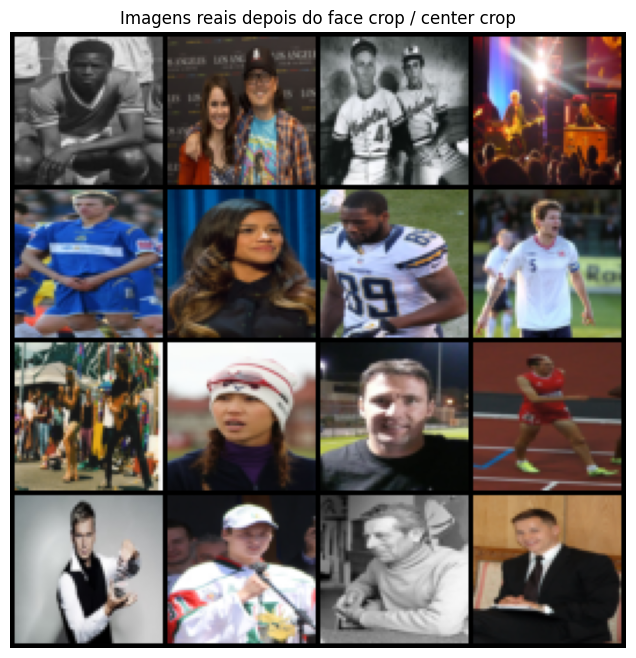

Grelha real guardada em: outputs\g7_sample_more_epochs\samples\real_facecrop_grid.png


In [45]:
real_batch = next(iter(dataloader))
real_batch = denorm_to_01(real_batch[:16].cpu())

grid = make_grid(real_batch, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Imagens reais depois do face crop / center crop")
plt.show()

real_grid_path = os.path.join(SAMPLES_DIR, "real_facecrop_grid.png")
save_image(grid, real_grid_path)
print("Grelha real guardada em:", real_grid_path)

## Inicialização de pesos

In [46]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

## Gerador

In [47]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, nc=3):
        super().__init__()
        self.init = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
        )
        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 8, ngf * 4, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 4, ngf * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 2, ngf, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.init(z)
        return self.main(x)

## Discriminador

In [48]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, dropout_p=0.2):
        super().__init__()
        self.main = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout_p),

            # 32x32 -> 16x16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout_p),

            # 16x16 -> 8x8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout_p),

            # 8x8 -> 4x4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.main(x).view(-1)

## Instanciar modelos

In [49]:
netG = Generator(LATENT_DIM, NGF, NUM_CHANNELS).to(DEVICE)
netD = Discriminator(NUM_CHANNELS, NDF, dropout_p=DROPOUT_P).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

netG_ema = copy.deepcopy(netG).to(DEVICE).eval()
for p in netG_ema.parameters():
    p.requires_grad_(False)

criterion = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))

fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)

print(netG)
print(netD)
print("EMA generator active:", USE_EMA)

Generator(
  (init): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Upsample(scale_factor=2.0, mode='nearest')
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## Treino — g6

In [50]:
from tqdm.auto import tqdm

from tqdm.auto import tqdm
import pandas as pd
import math

# ---- Calibrate & split sample output to ~90 MB files ----
import io, base64, json
from PIL import Image as PILImage

TARGET_MB = 90                                  # middle of [89, 92] MB range (safe)
TARGET_BYTES = TARGET_MB * 1024 * 1024

def _sample_line_bytes(generator, noise, nrow=8):
    """Produce one frame exactly as save_samples_jsonl would, return its JSONL line size in bytes."""
    generator.eval()
    with torch.no_grad():
        fake = generator(noise).detach().cpu()
        fake = (fake + 1) / 2
        grid = make_grid(fake, nrow=nrow, padding=2, normalize=False)
        arr = (grid.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype("uint8")
        buf = io.BytesIO()
        PILImage.fromarray(arr).save(buf, format="PNG", optimize=True)
        b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    generator.train()
    line = json.dumps({"epoch": 0, "format": "png", "grid_b64": b64}) + "\n"
    return len(line.encode("utf-8"))

frame_bytes = _sample_line_bytes(netG, fixed_noise)
total_bytes = frame_bytes * NUM_EPOCHS

EPOCHS_PER_SPLIT = max(1, TARGET_BYTES // frame_bytes)
NUM_SPLITS = math.ceil(NUM_EPOCHS / EPOCHS_PER_SPLIT)
last_epochs = NUM_EPOCHS - (NUM_SPLITS - 1) * EPOCHS_PER_SPLIT

full_mb = (EPOCHS_PER_SPLIT * frame_bytes) / (1024 * 1024)
last_mb = (last_epochs * frame_bytes) / (1024 * 1024)

print("Sample-file calibration")
print(f"  frame size:       ~{frame_bytes/1024:>7.1f} KB")
print(f"  projected total:  ~{total_bytes/1024/1024:>7.1f} MB  ({NUM_EPOCHS} epochs)")
print(f"  → {NUM_SPLITS} files: {NUM_SPLITS-1} × ~{full_mb:.1f} MB + 1 × ~{last_mb:.1f} MB")


JSON_OUT_DIR = os.path.join(OUTPUT_DIR,"json_samples")
SAMPLE_FILES = [
    os.path.join(JSON_OUT_DIR, f"samples_{k+1:02d}.jsonl")
    for k in range(NUM_SPLITS)
]

for p in SAMPLE_FILES: open(p, "w").close()      # truncate any previous run

def sample_file_for(epoch):
    return SAMPLE_FILES[min((epoch - 1) // EPOCHS_PER_SPLIT, NUM_SPLITS - 1)]

history = []
fid_history = []
g_losses, d_losses = [], []

history_path = os.path.join(METRICS_DIR, "training_history.csv")
fid_path = os.path.join(METRICS_DIR, "fid_kid_history.csv")
config_path = os.path.join(OUTPUT_DIR, "run_config.json")

run_config = {
    "run_name": RUN_NAME,
    "real_dir": REAL_DIR,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "latent_dim": LATENT_DIM,
    "ngf": NGF,
    "ndf": NDF,
    "num_epochs": NUM_EPOCHS,
    "lr_g": LR_G,
    "lr_d": LR_D,
    "beta1": BETA1,
    "real_label_low": REAL_LABEL_LOW,
    "real_label_high": REAL_LABEL_HIGH,
    "fake_label": FAKE_LABEL,
    "gen_target_label": GEN_TARGET_LABEL,
    "instance_noise_std_init": INSTANCE_NOISE_STD_INIT,
    "instance_noise_decay_epochs": INSTANCE_NOISE_DECAY_EPOCHS,
    "dropout_p": DROPOUT_P,
    "use_face_crop": USE_FACE_CROP,
    #"cv2_available": CV2_AVAILABLE,
    "face_crop_margin": FACE_CROP_MARGIN,
    "use_ema": USE_EMA,
    "ema_decay": EMA_DECAY,
    "best_checkpoint_metric": "fid",
    "final_model_selection": "best_fid_checkpoint",
    "seed": SEED,
    "start_fold": START_FOLD,
    "end_fold": END_FOLD,
    "interval": INTERVAL,
    "sample_every": SAMPLE_EVERY,
    "checkpoint_every": CHECKPOINT_EVERY,
    "fid_every": FID_EVERY,
    "fid_num_images": FID_NUM_IMAGES,
    "compute_kid": COMPUTE_KID,
    "num_workers": NUM_WORKERS,
    "num_real_images": len(dataset),
}
try:
    run_config["folds_used"] = list(dataset.fold_names)
except Exception:
    pass

with open(config_path, "w") as f:
    json.dump(run_config, f, indent=2)

best_fid = float("inf")
best_fid_epoch = None
best_checkpoint_path = os.path.join(CHECKPOINTS_DIR, "best_fid_checkpoint.pt")
best_sample_prefix = "best_fid_fixed_noise"

if SAVE_JSONL_EVERY is not None:
    samples_jsonl_path = os.path.join(OUTPUT_DIR, "samples_evolution.jsonl")
    open(samples_jsonl_path, "w").close()
else:
    samples_jsonl_path = None


def eval_generator():
    return netG_ema if USE_EMA else netG


save_generated_samples_png(0, eval_generator(), fixed_noise, prefix="fixed_noise_initial")

print("A começar treino g6...")
epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    epoch_dx = 0.0
    epoch_dgz_fake = 0.0
    epoch_dgz_gen = 0.0
    current_noise_std = instance_noise_std(epoch)

    batch_bar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=False, unit="batch")
    for real_images in batch_bar:
        real_images = real_images.to(DEVICE)
        b_size = real_images.size(0)

        # --- Discriminator ---
        netD.zero_grad(set_to_none=True)

        real_noisy = add_instance_noise(real_images, epoch)
        output_real = netD(real_noisy)
        real_targets = make_real_targets(b_size)
        lossD_real = criterion(output_real, real_targets)

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = netG(noise)
        fake_noisy = add_instance_noise(fake_images.detach(), epoch)
        output_fake = netD(fake_noisy)
        fake_targets = make_fake_targets(b_size)
        lossD_fake = criterion(output_fake, fake_targets)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # --- Generator ---
        netG.zero_grad(set_to_none=True)
        fake_for_g = add_instance_noise(fake_images, epoch)
        output_gen = netD(fake_for_g)
        gen_targets = make_gen_targets(b_size)
        lossG = criterion(output_gen, gen_targets)
        lossG.backward()
        optimizerG.step()

        if USE_EMA:
            update_ema(netG_ema, netG, EMA_DECAY)

        with torch.no_grad():
            dx = torch.sigmoid(output_real).mean().item()
            dgz_fake = torch.sigmoid(output_fake).mean().item()
            dgz_gen = torch.sigmoid(output_gen).mean().item()

        epoch_d_loss += lossD.item()
        epoch_g_loss += lossG.item()
        epoch_dx += dx
        epoch_dgz_fake += dgz_fake
        epoch_dgz_gen += dgz_gen

        batch_bar.set_postfix(d=f"{lossD.item():.3f}", g=f"{lossG.item():.3f}", dx=f"{dx:.2f}", noise=f"{current_noise_std:.3f}")

    n = len(dataloader)
    avg_d = epoch_d_loss / n
    avg_g = epoch_g_loss / n
    avg_dx = epoch_dx / n
    avg_dgz_fake = epoch_dgz_fake / n
    avg_dgz_gen = epoch_dgz_gen / n

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    row = {
        "run_name": RUN_NAME,
        "epoch": epoch,
        "loss_d": avg_d,
        "loss_g": avg_g,
        "D_x": avg_dx,
        "D_G_z_fake": avg_dgz_fake,
        "D_G_z_gen": avg_dgz_gen,
        "instance_noise_std": current_noise_std,
    }
    history.append(row)
    pd.DataFrame(history).to_csv(history_path, index=False)

    epoch_bar.set_postfix(loss_d=f"{avg_d:.3f}", loss_g=f"{avg_g:.3f}", d_x=f"{avg_dx:.2f}", dgz=f"{avg_dgz_gen:.2f}")

    if should_run(epoch, SAMPLE_EVERY):
        path = save_generated_samples_png(epoch, eval_generator(), fixed_noise, prefix="fixed_noise")
        print(f"[epoch {epoch}] samples guardadas em: {path}")

    # Save a frame every epoch into the current split file
    for _ in tqdm([0], desc=f"Saving epoch {epoch}", leave=False):
        save_samples_jsonl(epoch, netG, fixed_noise, sample_file_for(epoch))

    if should_run(epoch, CHECKPOINT_EVERY):
        ckpt_path = os.path.join(CHECKPOINTS_DIR, f"checkpoint_epoch_{epoch:03d}.pt")
        torch.save({
            "epoch": epoch,
            "netG_state_dict": netG.state_dict(),
            "netD_state_dict": netD.state_dict(),
            "netG_ema_state_dict": netG_ema.state_dict() if USE_EMA else None,
            "optimizerG_state_dict": optimizerG.state_dict(),
            "optimizerD_state_dict": optimizerD.state_dict(),
            "run_config": run_config,
            "history": history,
            "fid_history": fid_history,
        }, ckpt_path)

    if should_run(epoch, FID_EVERY):
        metrics = compute_fid_kid(
            eval_generator(),
            dataloader,
            num_images=FID_NUM_IMAGES,
            latent_dim=LATENT_DIM,
            device=DEVICE,
            compute_kid=COMPUTE_KID,
        )
        fid_row = {
            "fid": metrics["fid"],
            "kid_mean": metrics["kid_mean"],
            "kid_std": metrics["kid_std"],
            "run_name": RUN_NAME,
            "epoch": epoch,
            "evaluated_model": "ema" if USE_EMA else "raw_G",
        }
        fid_history.append(fid_row)
        pd.DataFrame(fid_history).to_csv(fid_path, index=False)
        print(f"[epoch {epoch}] FID={metrics['fid']:.4f} | KID={metrics['kid_mean']:.6f} ± {metrics['kid_std']:.6f}")

        if not math.isnan(metrics["fid"]) and metrics["fid"] < best_fid:
            best_fid = metrics["fid"]
            best_fid_epoch = epoch
            torch.save({
                "epoch": epoch,
                "best_fid": best_fid,
                "netG_state_dict": netG.state_dict(),
                "netD_state_dict": netD.state_dict(),
                "netG_ema_state_dict": netG_ema.state_dict() if USE_EMA else None,
                "optimizerG_state_dict": optimizerG.state_dict(),
                "optimizerD_state_dict": optimizerD.state_dict(),
                "run_config": run_config,
                "history": history,
                "fid_history": fid_history,
            }, best_checkpoint_path)
            best_sample_path = save_generated_samples_png(epoch, eval_generator(), fixed_noise, prefix=best_sample_prefix)
            print(f"Novo melhor FID: {best_fid:.4f} @ epoch {epoch}. Checkpoint: {best_checkpoint_path}")
            print("Sample do melhor FID:", best_sample_path)

# Guardar interpolação final com EMA/raw atual
interp_path = os.path.join(SAMPLES_DIR, "latent_interpolation_final.png")
save_latent_interpolation(eval_generator(), LATENT_DIM, DEVICE, interp_path)
print("Interpolação final guardada em:", interp_path)

print("Treino concluído.")
print("Melhor FID:", best_fid, "@ epoch", best_fid_epoch)

Sample-file calibration
  frame size:       ~  202.9 KB
  projected total:  ~    9.9 MB  (50 epochs)
  → 1 files: 0 × ~89.9 MB + 1 × ~9.9 MB
A começar treino g6...


Training:   0%|          | 0/50 [01:23<?, ?epoch/s, d_x=0.57, dgz=0.15, loss_d=1.389, loss_g=2.699]

[epoch 1] samples guardadas em: outputs\g7_sample_more_epochs\samples\fixed_noise_epoch_001.png


c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Training:   2%|▏         | 1/50 [01:28<1:12:20, 88.59s/epoch, d_x=0.57, dgz=0.15, loss_d=1.389, loss_g=2.699]

[epoch 1] FID=333.3497 | KID=0.314670 ± 0.010531
Novo melhor FID: 333.3497 @ epoch 1. Checkpoint: outputs\g7_sample_more_epochs\checkpoints\best_fid_checkpoint.pt
Sample do melhor FID: outputs\g7_sample_more_epochs\samples\best_fid_fixed_noise_epoch_001.png


...

[epoch 25] samples guardadas em: outputs\g7_sample_more_epochs\samples\fixed_noise_epoch_025.png


Training:  98%|█████████▊| 49/50 [1:08:28<01:21, 81.48s/epoch, d_x=0.70, dgz=0.19, loss_d=0.783, loss_g=2.028]

[epoch 50] samples guardadas em: outputs\g7_sample_more_epochs\samples\fixed_noise_epoch_050.png


c:\Users\hasht\anaconda3\envs\adversarial\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Training: 100%|██████████| 50/50 [1:08:33<00:00, 82.27s/epoch, d_x=0.70, dgz=0.19, loss_d=0.783, loss_g=2.028]

[epoch 50] FID=202.3734 | KID=0.078514 ± 0.010028
Novo melhor FID: 202.3734 @ epoch 50. Checkpoint: outputs\g7_sample_more_epochs\checkpoints\best_fid_checkpoint.pt
Sample do melhor FID: outputs\g7_sample_more_epochs\samples\best_fid_fixed_noise_epoch_050.png
Interpolação final guardada em: outputs\g7_sample_more_epochs\samples\latent_interpolation_final.png
Treino concluído.
Melhor FID: 202.3733673095703 @ epoch 50


## Curvas de treino

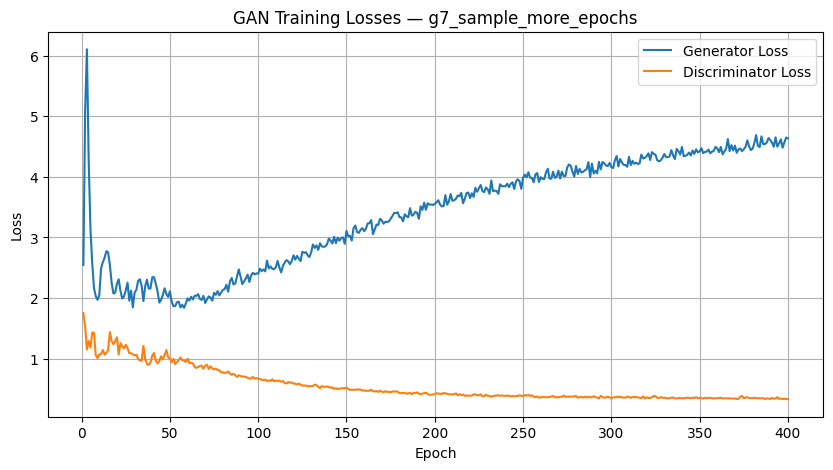

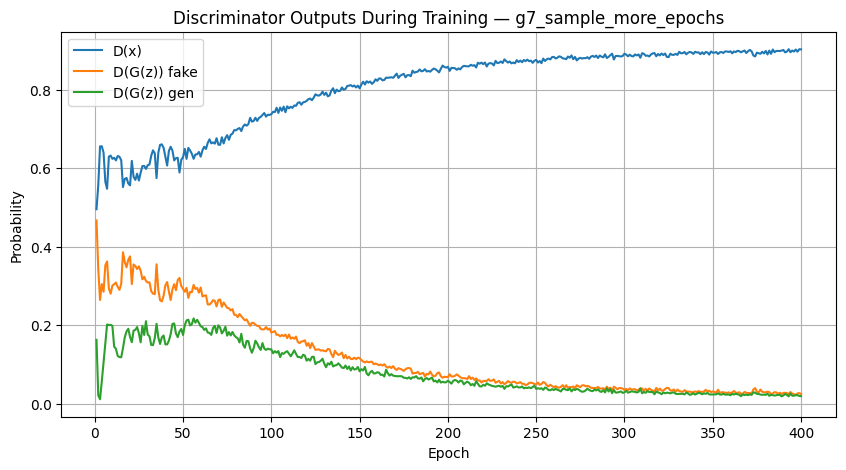

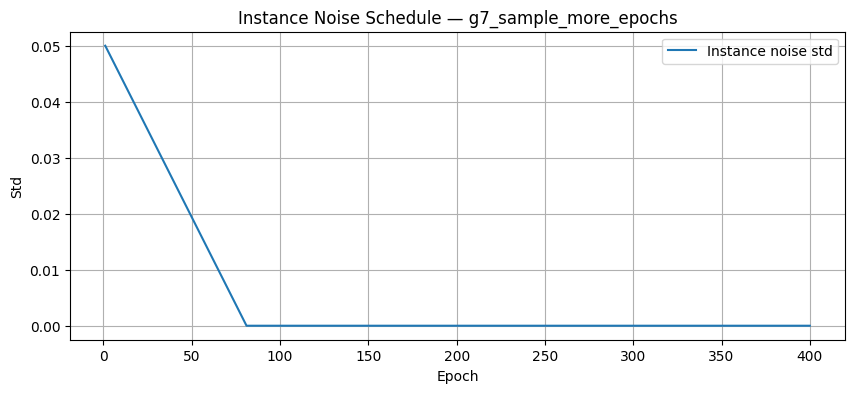

In [ ]:
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["loss_g"], label="Generator Loss")
plt.plot(history_df["epoch"], history_df["loss_d"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"GAN Training Losses — {RUN_NAME}")
plt.legend()
plt.grid(True)
loss_plot_path = os.path.join(PLOTS_DIR, "loss_curves.png")
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["D_x"], label="D(x)")
plt.plot(history_df["epoch"], history_df["D_G_z_fake"], label="D(G(z)) fake")
plt.plot(history_df["epoch"], history_df["D_G_z_gen"], label="D(G(z)) gen")
plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title(f"Discriminator Outputs During Training — {RUN_NAME}")
plt.legend()
plt.grid(True)
disc_plot_path = os.path.join(PLOTS_DIR, "discriminator_outputs.png")
plt.savefig(disc_plot_path, dpi=150, bbox_inches="tight")
plt.show()

if "instance_noise_std" in history_df.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["epoch"], history_df["instance_noise_std"], label="Instance noise std")
    plt.xlabel("Epoch")
    plt.ylabel("Std")
    plt.title(f"Instance Noise Schedule — {RUN_NAME}")
    plt.legend()
    plt.grid(True)
    noise_plot_path = os.path.join(PLOTS_DIR, "instance_noise_schedule.png")
    plt.savefig(noise_plot_path, dpi=150, bbox_inches="tight")
    plt.show()

Looking at the curves, the problem is clear: the discriminator has won. D(x) == 0.9 and D(G(z)) == 0.02 are indicative of near perfect classification, which starves the generator of useful gradients, which is why the G loss increases monotonically to 4.5.

## Curvas FID/KID

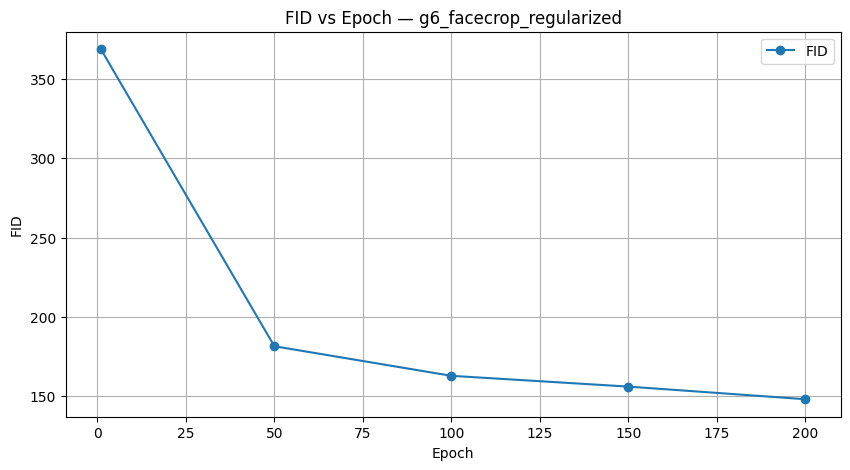

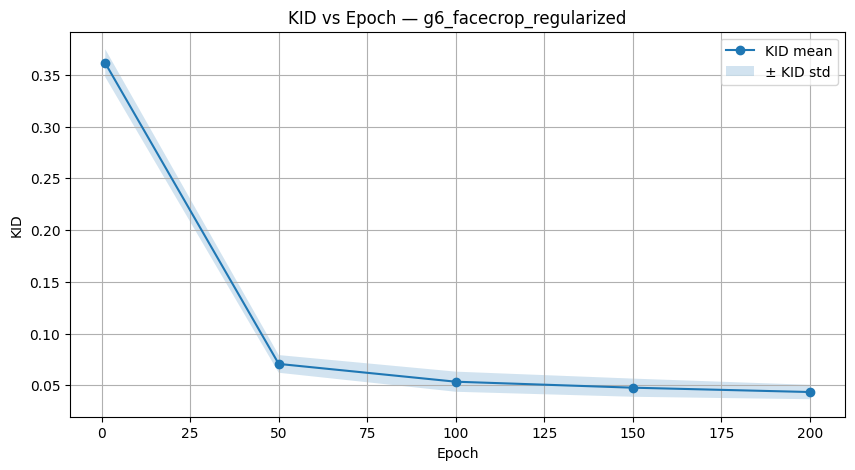

,fid,kid_mean,kid_std,run_name,epoch,evaluated_model
0,368.768250,0.361333,0.013437,g6_facecrop_regularized,1,ema
1,181.601791,0.070631,0.008547,g6_facecrop_regularized,50,ema
2,162.951889,0.053439,0.009724,g6_facecrop_regularized,100,ema
3,156.155167,0.047660,0.008785,g6_facecrop_regularized,150,ema
4,148.203156,0.043464,0.006956,g6_facecrop_regularized,200,ema


In [ ]:
if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)

    if "fid" in fid_df.columns and fid_df["fid"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["fid"], marker="o", label="FID")
        plt.xlabel("Epoch")
        plt.ylabel("FID")
        plt.title(f"FID vs Epoch — {RUN_NAME}")
        plt.legend()
        plt.grid(True)
        fid_plot_path = os.path.join(PLOTS_DIR, "fid_curve.png")
        plt.savefig(fid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("FID existe, mas está vazio/NaN. Verificar torchmetrics/torch-fidelity.")

    if "kid_mean" in fid_df.columns and fid_df["kid_mean"].notna().any():
        plt.figure(figsize=(10, 5))
        plt.plot(fid_df["epoch"], fid_df["kid_mean"], marker="o", label="KID mean")
        if "kid_std" in fid_df.columns:
            plt.fill_between(
                fid_df["epoch"],
                fid_df["kid_mean"] - fid_df["kid_std"],
                fid_df["kid_mean"] + fid_df["kid_std"],
                alpha=0.2,
                label="± KID std",
            )
        plt.xlabel("Epoch")
        plt.ylabel("KID")
        plt.title(f"KID vs Epoch — {RUN_NAME}")
        plt.legend()
        plt.grid(True)
        kid_plot_path = os.path.join(PLOTS_DIR, "kid_curve.png")
        plt.savefig(kid_plot_path, dpi=150, bbox_inches="tight")
        plt.show()

    display(fid_df)
else:
    print("Ainda não existe fid_kid_history.csv.")

## Gerar imagens com o melhor checkpoint

Best checkpoint epoch: 200
Best FID: 148.20315551757812


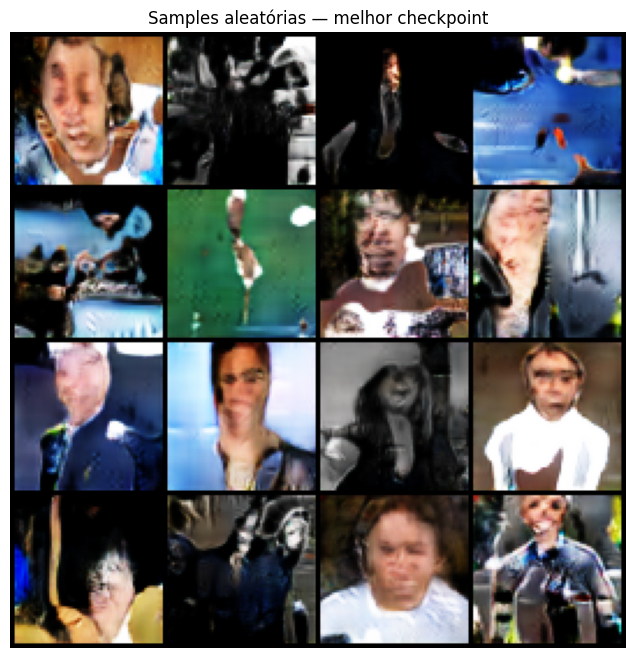

Samples guardadas em: outputs\g6_facecrop_regularized\samples\manual_random_samples_best_fid.png


In [ ]:
best_ckpt_path = os.path.join(CHECKPOINTS_DIR, "best_fid_checkpoint.pt")

if not os.path.exists(best_ckpt_path):
    print("Não existe best_fid_checkpoint.pt. Isto pode acontecer se FID não foi calculado.")
    print("Vou usar o modelo atual em memória.")
    best_gen = copy.deepcopy(netG_ema if USE_EMA else netG)
else:
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    print("Best checkpoint epoch:", ckpt.get("epoch"))
    print("Best FID:", ckpt.get("best_fid"))

    best_gen = copy.deepcopy(netG_ema if USE_EMA else netG)
    if USE_EMA and ckpt.get("netG_ema_state_dict") is not None:
        best_gen.load_state_dict(ckpt["netG_ema_state_dict"])
    else:
        best_gen.load_state_dict(ckpt["netG_state_dict"])

best_gen = best_gen.to(DEVICE)
best_gen.eval()

with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    fake_images = denorm_to_01(best_gen(noise).cpu())

grid = make_grid(fake_images, nrow=4, padding=2)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Samples aleatórias — melhor checkpoint")
plt.show()

manual_sample_path = os.path.join(SAMPLES_DIR, "manual_random_samples_best_fid.png")
save_image(grid, manual_sample_path)
print("Samples guardadas em:", manual_sample_path)

## Interpolação latente com o melhor checkpoint

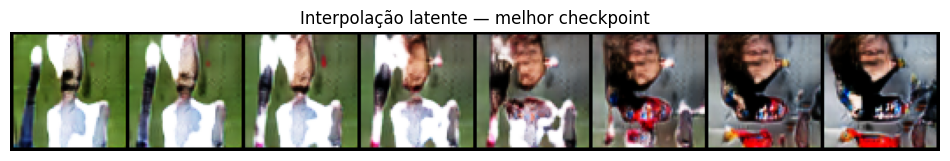

Interpolação guardada em: outputs\g6_facecrop_regularized\samples\latent_interpolation_best_fid.png


In [ ]:
interp_best_path = os.path.join(SAMPLES_DIR, "latent_interpolation_best_fid.png")
save_latent_interpolation(best_gen, LATENT_DIM, DEVICE, interp_best_path, steps=8, nrow=8)

img = PILImage.open(interp_best_path)
plt.figure(figsize=(12, 2))
plt.imshow(img)
plt.axis("off")
plt.title("Interpolação latente — melhor checkpoint")
plt.show()

print("Interpolação guardada em:", interp_best_path)

## Resumo automático da run

In [ ]:
summary = {
    "Iteration": "g6_facecrop_regularized",
    "Change": "Face crop / center crop fallback + one-sided label smoothing + decaying instance noise + discriminator dropout; keep EMA and best-FID checkpoint selection.",
    "FID @ end": None,
    "Best FID": None,
    "Best FID epoch": None,
    "Notes": "Testa se simplificar a distribuição visual e reduzir a saturação do discriminador melhora a qualidade do gerador face à g5.",
}

if os.path.exists(fid_path):
    fid_df = pd.read_csv(fid_path)
    if len(fid_df) > 0 and fid_df["fid"].notna().any():
        valid = fid_df.dropna(subset=["fid"])
        summary["FID @ end"] = float(valid.iloc[-1]["fid"])
        best_row = valid.sort_values("fid").iloc[0]
        summary["Best FID"] = float(best_row["fid"])
        summary["Best FID epoch"] = int(best_row["epoch"])

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "Iteration": "g6_facecrop_regularized",
  "Change": "Face crop / center crop fallback + one-sided label smoothing + decaying instance noise + discriminator dropout; keep EMA and best-FID checkpoint selection.",
  "FID @ end": 148.20315551757812,
  "Best FID": 148.20315551757812,
  "Best FID epoch": 200,
  "Notes": "Testa se simplificar a distribuição visual e reduzir a saturação do discriminador melhora a qualidade do gerador face à g5."
}


## Conclusão g6

**Comparação direta g5 vs g6:**

| Métrica           |                      g5 |                      g6 |
| ----------------- | ----------------------: | ----------------------: |
| Melhor FID        | **163.31** na epoch 100 | **148.20** na epoch 200 |
| Melhor KID mean   | **0.0483** na epoch 200 | **0.0435** na epoch 200 |
| Loss G final      |               ~**7.21** |               ~**4.40** |
| Loss D final      |               ~**0.06** |               ~**0.41** |
| D(x) final        |               ~**0.98** |               ~**0.88** |
| D(G(z)) gen final |              ~**0.008** |              ~**0.037** |

- Isto é uma melhoria importante.

- No g5, o discriminador estava praticamente perfeito. No g6, o discriminador continua mais forte que o gerador, mas já não está tão saturado. Ou seja, a regularização ajudou.

**O que melhorou:**

- O FID melhorou de 163.31 → 148.20, o que é uma melhoria relativa de cerca de 9.3%.

- Também é muito positivo que, ao contrário do g5, o FID do g6 melhora continuamente:

    - epoch 1: 368.77
    - epoch 50: 181.60
    - epoch 100: 162.95
    - epoch 150: 156.16
    - epoch 200: 148.20

- Isto mostra que a combinação face/center crop + regularização do D + EMA tornou o treino mais estável.

- A loss também está muito mais saudável. No g5, o loss_g disparava até ~7.2 e o loss_d caía quase para zero. No g6, o loss_g termina em ~4.4 e o loss_d fica por volta de ~0.4. Isto significa que o discriminador já não está a esmagar o gerador tão cedo.

**O que continua problemático:**

- Os crops confirmam um problema importante: o preprocessing ainda não está realmente a isolar faces. Vemos várias imagens que continuam a ter:

     corpo inteiro;
     pessoas muito pequenas;
     imagens de desporto;
     palcos/concertos;
     mais de uma pessoa;
     crops sem rosto claro.

- Portanto, o g6 melhorou, mas provavelmente não por ter feito um “face crop” perfeito. Melhorou porque:

     reduziu um pouco a variabilidade das imagens;
     aplicou regularização ao discriminador;
     manteve o EMA;
     o treino ficou mais equilibrado.

- Mas ainda há muito ruído visual no dataset. Para uma DCGAN 64×64, isto continua a ser difícil.

**Interpretação das imagens geradas:**

- As imagens do g6 parecem melhores em distribuição geral, mas ainda não são faces convincentes. Há mais consistência do que no g5, mas continuam a aparecer:

     rostos deformados;
     fundos misturados com pessoas;
     corpos incompletos;
     texturas pouco naturais;
     alguns samples quase abstratos.

- Isto bate certo com o diagnóstico: o modelo melhorou quantitativamente, mas a qualidade perceptual ainda é limitada pela arquitetura e pelo preprocessing.

---

Na experiência g6, introduzimos um pré-processamento baseado em face crop, com fallback para center crop, e adicionámos regularização ao discriminador através de one-sided label smoothing, instance noise e dropout. Embora a deteção facial não tenha sido perfeita devido à grande variabilidade das imagens do dataset, esta experiência reduziu parcialmente a complexidade da distribuição e tornou o treino mais equilibrado. O FID melhorou de 163.31 no g5 para 148.20 no g6, e o KID também diminuiu de 0.0483 para 0.0435. Além disso, os outputs do discriminador deixaram de estar tão saturados, indicando que o gerador passou a receber sinais de treino mais úteis.